In [1]:
import shap
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [28]:
import pandas as pd

fraud_df = pd.read_csv(
    "../data/processed/fraud_processed.csv"
)

y = fraud_df["class"]

X = fraud_df.drop("class", axis=1)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [11]:
X = fraud_df.drop("class", axis=1)
y = fraud_df["class"]

In [37]:
X = X.drop(columns=[
    'signup_time',
    'purchase_time',
    'device_id',
    'source', 'browser', 'sex', 'country'
])

In [36]:
print(X.select_dtypes(include=["object"]).columns.tolist())

['signup_time', 'purchase_time', 'device_id', 'source', 'browser', 'sex', 'country']


In [20]:
X_train.dtypes[X_train.dtypes == "object"]

signup_time      object
purchase_time    object
device_id        object
source           object
browser          object
sex              object
country          object
dtype: object

In [38]:
X = X.astype(float)

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [34]:
print(X_train.select_dtypes(include=["object"]).columns.tolist())

['signup_time', 'purchase_time', 'device_id', 'source', 'browser', 'sex', 'country']


In [35]:
print(X.select_dtypes(include=["object"]).columns.tolist())


['signup_time', 'purchase_time', 'device_id', 'source', 'browser', 'sex', 'country']


In [40]:
from sklearn.ensemble import RandomForestClassifier

best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

best_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [42]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

top10 = feature_importance.head(10)

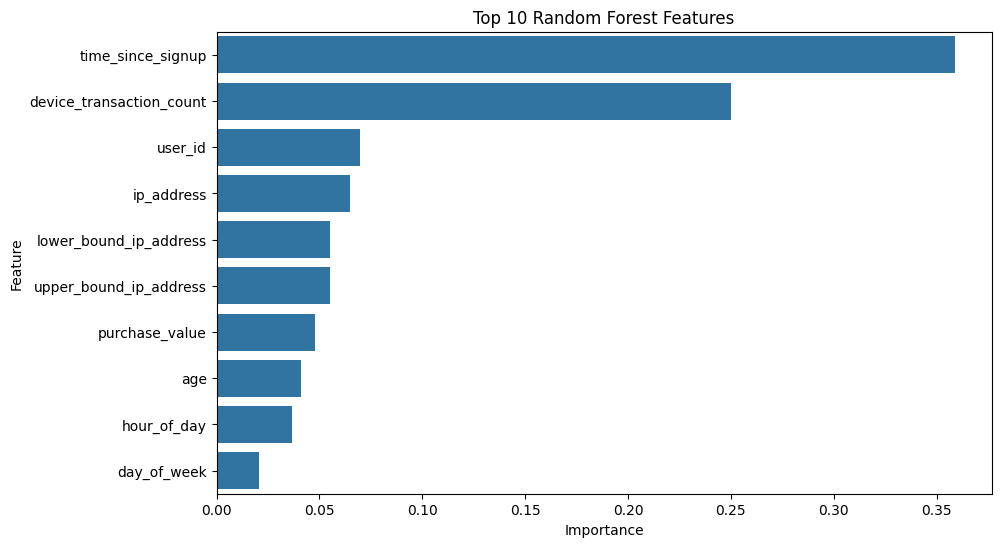

In [43]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Random Forest Features"
)

plt.show()

In [ ]:
explainer = shap.TreeExplainer(
    best_rf
)

shap_values = explainer.shap_values(
    X_test
)

In [ ]:
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(25830, 11, 2)


In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

In [ ]:
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "SHAP Importance":
        np.abs(
            shap_values[:, :, 1]
        ).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "SHAP Importance",
    ascending=False
)

shap_importance.head(10)

In [ ]:
preds = best_rf.predict(X_test)

In [54]:
tp_idx = np.where(
    (y_test.values == 1) &
    (preds == 1)
)[0][0]

print(tp_idx)

37


In [53]:
fp_idx = np.where(
    (y_test.values == 0) &
    (preds == 1)
)[0][0]

print(fp_idx)

4502


In [ ]:
fn_idx = np.where(
    (y_test.values == 1) &
    (preds == 0)
)[0][0]

print(fn_idx)

3


In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1],
    shap_values[tp_idx, :, 1],
    X_test.iloc[tp_idx]
)

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[fp_idx, :, 1],
    X_test.iloc[fp_idx]
)

In [ ]:
shap.force_plot(
    explainer.expected_value[1],
    shap_values[fn_idx, :, 1],
    X_test.iloc[fn_idx]
)

In [55]:
shap_importance

,Feature,SHAP Importance
6,time_since_signup,0.061435
10,device_transaction_count,0.047550
3,ip_address,0.008219
4,lower_bound_ip_address,0.007143
5,upper_bound_ip_address,0.005683
0,user_id,0.004077
1,purchase_value,0.003702
7,hour_of_day,0.003660
2,age,0.003620
8,day_of_week,0.003585


In [56]:
print(feature_importance.head(10))
print(shap_importance.head(10))

                     Feature  Importance
6          time_since_signup    0.358833
10  device_transaction_count    0.249990
0                    user_id    0.069786
3                 ip_address    0.065028
4     lower_bound_ip_address    0.055198
5     upper_bound_ip_address    0.055044
1             purchase_value    0.047749
2                        age    0.041207
7                hour_of_day    0.036441
8                day_of_week    0.020725
                     Feature  SHAP Importance
6          time_since_signup         0.061435
10  device_transaction_count         0.047550
3                 ip_address         0.008219
4     lower_bound_ip_address         0.007143
5     upper_bound_ip_address         0.005683
0                    user_id         0.004077
1             purchase_value         0.003702
7                hour_of_day         0.003660
2                        age         0.003620
8                day_of_week         0.003585
